# House Price Prediction Project
**Goal:** We want to build an AI model that looks at house details (like area, rooms) and predicts its final `SalePrice`.

### Phase 1: What we have done so far?
1. **Created a Project Folder:** Set up the environment using `uv`.
2. **Downloaded Data:** Got the official `train.csv` and `test.csv` files from Kaggle.
   - **Train Data:** Contains house details AND the final price (AI learns from this).
   - **Test Data:** Contains house details but NO price (AI will guess this later).
3. **Loaded Libraries & Data:** Brought our data into Python using Pandas.

In [1]:
#===================================
# STEP 1: IMPORTING TOOLS (LIBRARIES)
#===================================

# import pandas: This acts like Microsoft Excel for python. It helps us read , clean  and view data tables
# Import Matplotlib: This tool give us a blank canvas to draw basic charts & graphs
import matplotlib.pyplot as plt

#Import Numpy: This act like as a fast calculator for doing math on big numbers
import numpy as np  # noqa: F401, RUF100
import pandas as pd

# Import Seaborn: This tool helps us create more attractive and informative statistical graphics
import seaborn as sns

#Tell pandas not to hide any column. we want to see all 80+ columns on our screen
pd.set_option('display.max_columns', None)

print("All tools are ready")

All tools are ready


In [2]:
# ==========================================
# STEP 2: LOADING THE CSV FILES
# ==========================================

train_path = r"E:\new_projects\House_pridiction_price_project\data\train.csv"
test_path  = r"E:\new_projects\House_pridiction_price_project\data\test.csv"


df_train = pd.read_csv(train_path)
df_test =  pd.read_csv(test_path)

print(f"Shape of df_train: {df_train.shape}")
print(f"Shape of df_test:  {df_test.shape}")

Shape of df_train: (1460, 81)
Shape of df_test:  (1459, 80)


In [3]:
# Display all columns without hiding any (Safe & Recommended)
pd.set_option("display.max_columns", None)

In [4]:
df_train.head() # Display the first few rows of the training dataset

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
df_test.head() 
# Display the first few rows of the test dataset


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


# Data Preprocessing Kya Hai Aur Kyun Zaroori Hai?

Sochein aap biryani bana rahe hain. Agar chawal kharab hain ya namak zyada hai, toh biryani bhi kharab banegi. Bilkul waise hi, agar data ganda hai toh model bhi ghalat jawab dega. Preprocessing ka matlab hai:

- Ghalat ya adhoori information hatana (missing values)
- Cheezon ko sahi format mein lana (numbers vs text)
- Faaltu columns hata dena jo kaam ke nahi

Kaunse Features Price Pe Asar Daalte Hain?

1. OverallQual -> Ghar ki quality (1-10) 10 = Bohot acha, 1 = Bohot kharab

2. GrLivArea   -> Ghar ka size (sq ft) 2000 sq ft > 1000 sq ft = Mehnga

3. YearBuilt   -> Kab bana  2020 ka ghar > 1950 ka ghar

4. Neighborhood  -> Ilaqa -> NridgHt mehnga, MeadowV sasta

5. GarageCars  ->   Kitni gaariyan aayein  3 cars > 1 car

6. FullBath   ->    Bathrooms  -> Zyada bathroom = Zyada price

7. TotalBsmtSF  ->  Basement ka size  -> Bada basement = Mehnga

8. KitchenQual  ->  Kitchen kaisa hai  -> Ex (Excellent) > Po (Poor) 

# 🔑 Essential DataFrame Inspection Methods (The 80/20 Rule)

When beginning Exploratory Data Analysis (EDA) in **pandas**, these four commands provide the majority of the initial structural insights needed to understand your dataset.

## 1. `df.shape` — Dataset Dimensions
* **Type:** Attribute (no parentheses `()`)
* **Purpose:** Returns a tuple indicating the number of rows and columns: `(rows, columns)`.
* **Interpretation:** An output like `(1460, 81)` means the dataset contains **1,460 rows (records)** and **81 columns (features)**.

## 2. `df.columns` — Feature Names
* **Type:** Attribute (no parentheses `()`)
* **Purpose:** Returns an `Index` object containing all column names.
* **Interpretation:** Use this to verify exact column naming conventions, capitalization, and whitespace.

## 3. `df.head(n=5)` — Preview Initial Records
* **Type:** Method
* **Purpose:** Returns the first `n` rows of the DataFrame (default is `5`).
* **Interpretation:** Provides a quick visual inspection of the actual data values and format.

## 4. `df.info()` — Data Types & Missing Values
* **Type:** Method
* **Purpose:** Prints a concise summary including total entries, column data types (`dtypes`), and non-null (non-missing) counts.
* **Interpretation:** Essential for spotting **missing values** and detecting incorrect data types (e.g., numbers stored as strings).

---

### 📋 Quick Reference Summary

| Command | Type | Purpose | Primary Output |
| :--- | :--- | :--- | :--- |
| `df.shape` | Attribute | Check size | `(rows, columns)` tuple |
| `df.columns` | Attribute | View feature names | Array of column labels |
| `df.head(n)` | Method | Inspect data sample | First `n` rows (default: 5) |
| `df.info()` | Method | Check dtypes & nulls | Summary report |

# Data Se Insights Nikalna (Exploratory Data Analysis)


 Model banane se pehle data ko samajhna sabse zaroori hai. Insights nikalne ka matlab hai: "Data ke andar chupe hue aise patterns dhoondna jo ghar ki price (SalePrice) ko affect karte hain."

 Summary:

 - 1. Target Variable (SalePrice) ka overview: Average price kya hai? Min/Max kya hai?
 - 2. Numerical Correlation: Kaunse numerical columns (jaise area, quality) price ke sath sabse zyada related hain?
 - 3. Categorical Impact: Kaunse areas (Neighborhood) ya ghar ki styles (HouseStyle) mehngi hain?

## Know your Data:

### Will Use this feature while converting into numerical format / Encoding 
1. Nighborhooh
2. Overall Qual
3. YearBuilt
4. Foundation
5. Electircal
6. KitchenQual
7. GrageType
8. GarageFinish
9. Fence

## Data-Integration

In [6]:
df = pd.concat([df_train, df_test])

print(f"Shape of integrated dataframe: {df.shape}")

Shape of integrated dataframe: (2919, 81)


In [7]:
df.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706.0,Unf,0.0,150.0,856.0,GasA,Ex,Y,SBrkr,856,854,0,1710,1.0,0.0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2.0,548.0,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,Ex,Y,SBrkr,1262,0,0,1262,0.0,1.0,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2.0,460.0,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0,Unf,0.0,434.0,920.0,GasA,Ex,Y,SBrkr,920,866,0,1786,1.0,0.0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2.0,608.0,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,Gd,Y,SBrkr,961,756,0,1717,1.0,0.0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3.0,642.0,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0,Unf,0.0,490.0,1145.0,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1.0,0.0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3.0,836.0,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0


In [8]:
df.tail() # see the last line of the combined dataframe

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1454,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,Twnhs,2Story,4,7,1970,1970,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Unf,0.0,Unf,0.0,546.0,546.0,GasA,Gd,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,5,Typ,0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal,NaN
1455,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,TwnhsE,2Story,4,5,1970,1970,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,252.0,Unf,0.0,294.0,546.0,GasA,TA,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,6,Typ,0,NaN,CarPort,1970.0,Unf,1.0,286.0,TA,TA,Y,0,24,0,0,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml,NaN
1456,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1Story,5,7,1960,1996,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,ALQ,1224.0,Unf,0.0,0.0,1224.0,GasA,Ex,Y,SBrkr,1224,0,0,1224,1.0,0.0,1,0,4,1,TA,7,Typ,1,TA,Detchd,1960.0,Unf,2.0,576.0,TA,TA,Y,474,0,0,0,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml,NaN
1457,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,SFoyer,5,5,1992,1992,Gable,CompShg,HdBoard,Wd Shng,NaN,0.0,TA,TA,PConc,Gd,TA,Av,GLQ,337.0,Unf,0.0,575.0,912.0,GasA,TA,Y,SBrkr,970,0,0,970,0.0,1.0,1,0,3,1,TA,6,Typ,0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,Y,80,32,0,0,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,NaN
1458,2919,60,RL,74.0,9627,Pave,NaN,Reg,Lvl,AllPub,Inside,Mod,Mitchel,Norm,Norm,1Fam,2Story,7,5,1993,1994,Gable,CompShg,HdBoard,HdBoard,BrkFace,94.0,TA,TA,PConc,Gd,TA,Av,LwQ,758.0,Unf,0.0,238.0,996.0,GasA,Ex,Y,SBrkr,996,1004,0,2000,0.0,0.0,2,1,3,1,TA,9,Typ,1,TA,Attchd,1993.0,Fin,3.0,650.0,TA,TA,Y,190,48,0,0,0,0,NaN,NaN,NaN,0,11,2006,WD,Normal,NaN


## Get the brief information of data-set

In [9]:
df.info()

<class 'pandas.DataFrame'>
Index: 2919 entries, 0 to 1458
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             2919 non-null   int64  
 1   MSSubClass     2919 non-null   int64  
 2   MSZoning       2915 non-null   str    
 3   LotFrontage    2433 non-null   float64
 4   LotArea        2919 non-null   int64  
 5   Street         2919 non-null   str    
 6   Alley          198 non-null    str    
 7   LotShape       2919 non-null   str    
 8   LandContour    2919 non-null   str    
 9   Utilities      2917 non-null   str    
 10  LotConfig      2919 non-null   str    
 11  LandSlope      2919 non-null   str    
 12  Neighborhood   2919 non-null   str    
 13  Condition1     2919 non-null   str    
 14  Condition2     2919 non-null   str    
 15  BldgType       2919 non-null   str    
 16  HouseStyle     2919 non-null   str    
 17  OverallQual    2919 non-null   int64  
 18  OverallCond    2919 non-

In [10]:
# Select only the columns that have 'int64' (integer) data type

int_feature = df.select_dtypes(include=['int64']).columns

# Print the total count of these integer columns
print(f"The total number of integer column is: {int_feature.shape[0]}")

#Print the actual names of these columns to check for traps!
print("\nList of integer columns:")
print(int_feature.tolist())  # .tolist() makes it easier to read


The total number of integer column is: 26

List of integer columns:
['Id', 'MSSubClass', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']


In [11]:
# Select only the columns that have 'float64' (floating point) data type

float_feature = df.select_dtypes(include=['float64']).columns

# Print the total count of these float columns
print(f"The total number of float column is: {float_feature.shape[0]}")

#Print the actual names of these columns to check for traps!
print("\nList of float columns:")
print(float_feature.tolist())  # .tolist() makes it easier to read


The total number of float column is: 12

List of float columns:
['LotFrontage', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'SalePrice']


In [12]:
# Select only the columns that have 'object' (string) data type

object_feature = df.select_dtypes(include=['object', 'string']).columns

# Print the total count of these object columns
print(f"The total number of categorical column is: {object_feature.shape[0]}")

#Print the actual names of these columns to check for traps!
print("\nList of categorical columns:")
print(object_feature.tolist())  # .tolist() makes it easier to read

The total number of categorical column is: 43

List of categorical columns:
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


## Get the Statistical Information of Numerical Features

In [13]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,2919.000000,2919.000000,2433.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2896.000000,2918.000000,2918.000000,2918.000000,2918.000000,2919.000000,2919.000000,2919.000000,2919.000000,2917.000000,2917.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2760.000000,2918.000000,2918.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,1460.000000
mean,1460.000000,57.137718,69.305795,10168.114080,6.089072,5.564577,1971.312778,1984.264474,102.201312,441.423235,49.582248,560.772104,1051.777587,1159.581706,336.483727,4.694416,1500.759849,0.429894,0.061364,1.568003,0.380267,2.860226,1.044536,6.451524,0.597122,1978.113406,1.766621,472.874572,93.709832,47.486811,23.098321,2.602261,16.062350,2.251799,50.825968,6.213087,2007.792737,180921.195890
std,842.787043,42.517628,23.344905,7886.996359,1.409947,1.113131,30.291442,20.894344,179.334253,455.610826,169.205611,439.543659,440.766258,392.362079,428.701456,46.396825,506.051045,0.524736,0.245687,0.552969,0.502872,0.822693,0.214462,1.569379,0.646129,25.574285,0.761624,215.394815,126.526589,67.575493,64.244246,25.188169,56.184365,35.663946,567.402211,2.714762,1.314964,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1895.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,730.500000,20.000000,59.000000,7478.000000,5.000000,5.000000,1953.500000,1965.000000,0.000000,0.000000,0.000000,220.000000,793.000000,876.000000,0.000000,0.000000,1126.000000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1960.000000,1.000000,320.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129975.000000
50%,1460.000000,50.000000,68.000000,9453.000000,6.000000,5.000000,1973.000000,1993.000000,0.000000,368.500000,0.000000,467.000000,989.500000,1082.000000,0.000000,0.000000,1444.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1979.000000,2.000000,480.000000,0.000000,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,2189.500000,70.000000,80.000000,11570.000000,7.000000,6.000000,2001.000000,2004.000000,164.000000,733.000000,0.000000,805.500000,1302.000000,1387.500000,704.000000,0.000000,1743.500000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,2919.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1526.000000,2336.000000,6110.000000,5095.000000,2065.000000,1064.000000,5642.000000,3.000000,2.000000,4.000000,2.000000,8.000000,3.000000,15.000000,4.000000,2207.000000,5.000000,1488.000000,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [14]:
df.describe().shape

(8, 38)

## Data Cleaning

## Handeling Missing Value

## Visualize null/missing-value

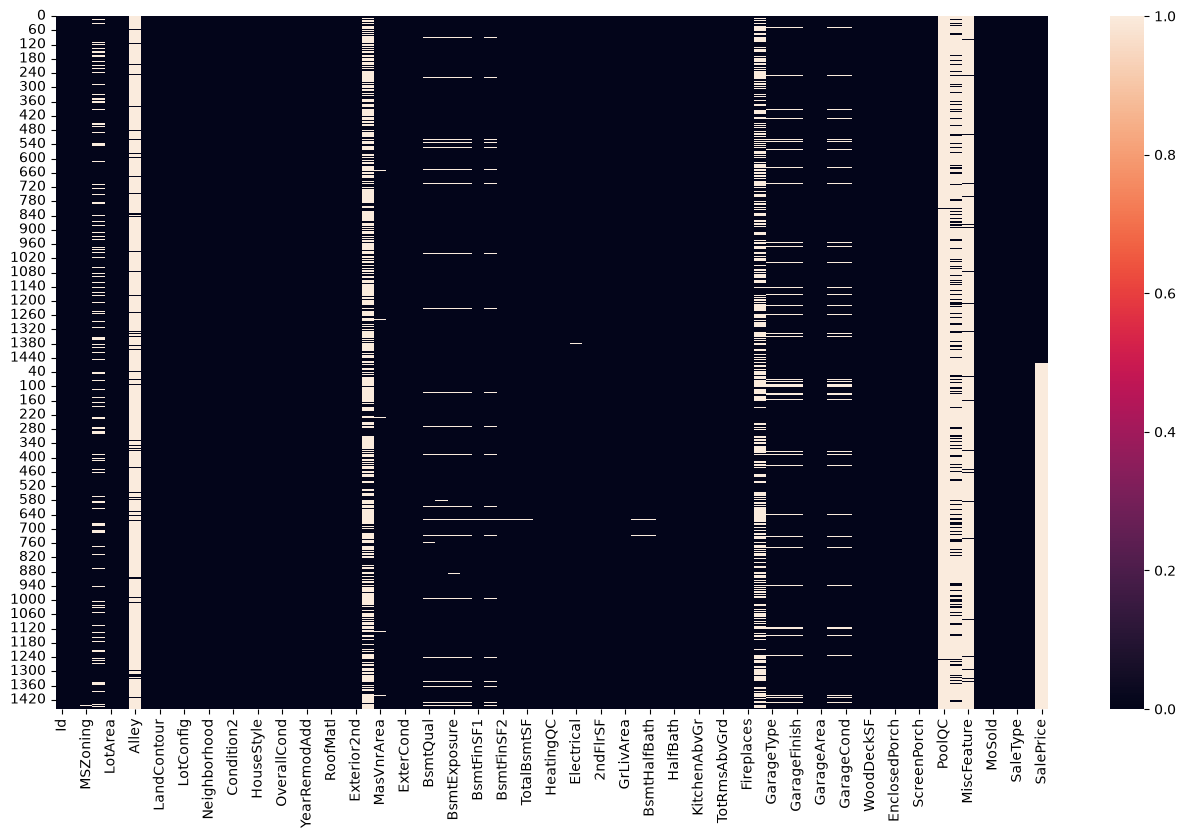

In [15]:
# 1. Canvas (Drawing Board) ka size set karna
plt.figure(figsize=(16, 9))  
# Purpose: Yeh line ek khali drawing board banati hai jo 16 inch chouda (width) aur 9 inch lamba (height) hai. 
# Isse heatmap bada aur saaf dikhta hai, chota aur crowded nahi hota.

# 2. ka purpose hai: Missing values (NaN/NA) ko ek colorful map ki tarah dekhna.
#Yeh line aapko ek jhalak (snapshot) mein dikha deti hai ke aapke pure dataset mein kahan-kahan data missing hai.
sns.heatmap(df.isnull())

# 3. ka purpose hai: Aapke banaye hue graph (chart) ko ek Image file (jaise .png ya .jpg) ki tarah aapke computer mein save karna.
#Jab aap plt.show() chalate hain, toh graph sirf screen par dikhta hai. Lekin jab aapko yeh graph kisi report,
# sentation, ya apne teacher/boss ko WhatsApp/Email par bhejna ho, toh aap plt.savefig() use karte hain.

plt.savefig("EDA_img/heatmap_DF_of_null_values.png")

## Get null value Percentage for every percentage

In [16]:
# set index as a id column
df.set_index("Id")

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706.0,Unf,0.0,150.0,856.0,GasA,Ex,Y,SBrkr,856,854,0,1710,1.0,0.0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2.0,548.0,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,Ex,Y,SBrkr,1262,0,0,1262,0.0,1.0,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2.0,460.0,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0,Unf,0.0,434.0,920.0,GasA,Ex,Y,SBrkr,920,866,0,1786,1.0,0.0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2.0,608.0,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,Gd,Y,SBrkr,961,756,0,1717,1.0,0.0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3.0,642.0,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0,Unf,0.0,490.0,1145.0,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1.0,0.0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3.0,836.0,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,Twnhs,2Story,4,7,1970,1970,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Unf,0.0,Unf,0.0,546.0,546.0,GasA,Gd,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,5,Typ,0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal,NaN
2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,TwnhsE,2Story,4,5,1970,1970,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,252.0,Unf,0.0,294.0,546.0,GasA,TA,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,6,Typ,0,NaN,CarPort,1970.0,Unf,1.0,286.0,TA,TA,Y,0,24,0,0,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml,NaN
2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1Story,5,7,1960,1996,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,ALQ,1224.0,Unf,0.0,0.0,1224.0,GasA,Ex,Y,SBrkr,1224,0,0,1224,1.0,0.0,1,0,4,1,TA,7,Typ,1,TA,Detchd,1960.0,Unf,2.0,576.0,TA,TA,Y,474,0,0,0,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml,NaN


In [17]:

# Calculate missing values for all columns
null_percentage = df.isnull().sum()

# Filter and show ONLY columns that have missing values (> 0)
null_count = null_percentage[null_percentage > 0]

null_count


MSZoning           4
LotFrontage      486
Alley           2721
Utilities          2
Exterior1st        1
Exterior2nd        1
MasVnrType      1766
MasVnrArea        23
BsmtQual          81
BsmtCond          82
BsmtExposure      82
BsmtFinType1      79
BsmtFinSF1         1
BsmtFinType2      80
BsmtFinSF2         1
BsmtUnfSF          1
TotalBsmtSF        1
Electrical         1
BsmtFullBath       2
BsmtHalfBath       2
KitchenQual        1
Functional         2
FireplaceQu     1420
GarageType       157
GarageYrBlt      159
GarageFinish     159
GarageCars         1
GarageArea         1
GarageQual       159
GarageCond       159
PoolQC          2909
Fence           2348
MiscFeature     2814
SaleType           1
SalePrice       1459
dtype: int64

In [18]:
# Tell Pandas to show ALL rows, no matter how many there are
pd.set_option('display.max_rows', None)

# Now calculate and print the percentage
null_percentage = (df.isnull().sum()/df.shape[0]*100)


null_percentage


Id                0.000000
MSSubClass        0.000000
MSZoning          0.137033
LotFrontage      16.649538
LotArea           0.000000
Street            0.000000
Alley            93.216855
LotShape          0.000000
LandContour       0.000000
Utilities         0.068517
LotConfig         0.000000
LandSlope         0.000000
Neighborhood      0.000000
Condition1        0.000000
Condition2        0.000000
BldgType          0.000000
HouseStyle        0.000000
OverallQual       0.000000
OverallCond       0.000000
YearBuilt         0.000000
YearRemodAdd      0.000000
RoofStyle         0.000000
RoofMatl          0.000000
Exterior1st       0.034258
Exterior2nd       0.034258
MasVnrType       60.500171
MasVnrArea        0.787941
ExterQual         0.000000
ExterCond         0.000000
Foundation        0.000000
BsmtQual          2.774923
BsmtCond          2.809181
BsmtExposure      2.809181
BsmtFinType1      2.706406
BsmtFinSF1        0.034258
BsmtFinType2      2.740665
BsmtFinSF2        0.034258
B

# Drop Column/Features
## As per my observation i will not drop any feature

In [19]:
# find the columns where missing value percentage is greater than 50%
miss_value_50_perc = null_percentage[null_percentage > 50]

miss_value_50_perc

Alley          93.216855
MasVnrType     60.500171
PoolQC         99.657417
Fence          80.438506
MiscFeature    96.402878
dtype: float64

In [20]:

"""
As Per our Domain Knowledge, we can not drop columns with more than 50% missing values, instead we should use constant values to fill them 'NA'.
"""

miss_value_50_perc = null_percentage[null_percentage > 50]

miss_value_50_perc

Alley          93.216855
MasVnrType     60.500171
PoolQC         99.657417
Fence          80.438506
MiscFeature    96.402878
dtype: float64

In [21]:
df["Alley"].value_counts()




Alley
Grvl    120
Pave     78
Name: count, dtype: int64

In [22]:
df["PoolQC"].value_counts()

PoolQC
Ex    4
Gd    4
Fa    2
Name: count, dtype: int64

In [23]:
df["Fence"].value_counts()

Fence
MnPrv    329
GdPrv    118
GdWo     112
MnWw      12
Name: count, dtype: int64

In [24]:
df["MiscFeature"].value_counts()

MiscFeature
Shed    95
Gar2     5
Othr     4
TenC     1
Name: count, dtype: int64

In [25]:
"""As per our domain knowledge we will not drop 'FireplaceQu' feature instead None Value add constant Value 'N/A' """

miss_value_20_50_perc = null_percentage[(null_percentage > 20) & (null_percentage <= 50)]
miss_value_20_50_perc

FireplaceQu    48.646797
SalePrice      49.982871
dtype: float64

In [26]:

miss_value_5_20_perc = null_percentage[(null_percentage > 5) & (null_percentage <= 20)]
miss_value_5_20_perc

LotFrontage     16.649538
GarageType       5.378554
GarageYrBlt      5.447071
GarageFinish     5.447071
GarageQual       5.447071
GarageCond       5.447071
dtype: float64

In [27]:
df["LotFrontage"].value_counts().head() # importane feature we will not remove becuase it tells us street distance

LotFrontage
60.0    276
80.0    137
70.0    133
50.0    117
75.0    105
Name: count, dtype: int64

<Axes: >

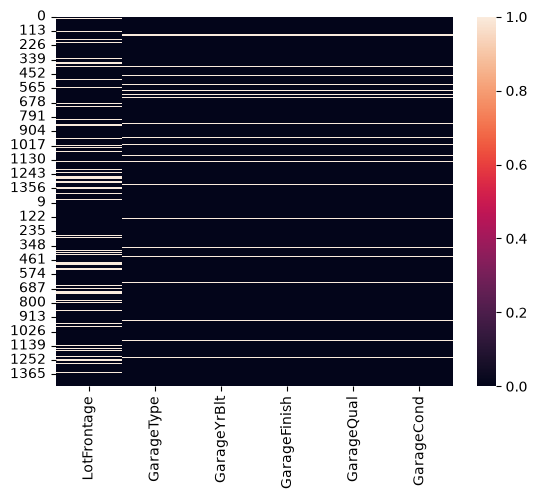

In [28]:
# 1. Get the names of columns that have 5% to 20% missing values
# 2. Select only those specific columns from the main dataframe 'df'
# 3. Check for missing values in these selected columns (returns True/False)
# 4. Draw a heatmap to visually see where the data is missing (Yellow = Missing, Dark = 

sns.heatmap(df[miss_value_5_20_perc.keys()].isnull())

## Mising Value Imputation:

 - Missing Value Imputation means filling in the empty (missing/NaN) values that exist in the data..
 - Machine Learning models can't understand empty data (NaN) and throw an error,
 - which is why we replace these missing values with some logical value.

## Key Points (80/20 Rule for Industry)

In the industry, we don't use super complex imputation every day. In 80% of cases, these simple techniques get the job done:

1. Mean (Average): Use it when all numbers are normal and balanced — no crazy big or crazy small values.
2. Median (Middle Value): Use it when some numbers are crazy big or crazy small (these are called outliers).
3. Why Median? Because Median doesn't care about crazy big or small numbers. It stays safe in the middle.

For Text / Categories (Categorical Data):
1. Mode (Most Frequent): Fill the missing spot with whatever value shows up the most. Simple.

Golden Rule of ML (Very Important!):
1. First, teach the imputer using only the Training data (fit).
2. Then, use that same learning to fill missing values in both Training and Test data (transform).
3. Why? So that "Data Leakage" doesn't happen. (Data Leakage = when test data info sneaks into training and cheats the results.)


In [29]:
# get the total_missing value feature

missing_value_feat = null_percentage[null_percentage > 0]

print(f"Total missing value features: {len(missing_value_feat)}")

Total missing value features: 35


In [30]:
missing_value_feat

MSZoning         0.137033
LotFrontage     16.649538
Alley           93.216855
Utilities        0.068517
Exterior1st      0.034258
Exterior2nd      0.034258
MasVnrType      60.500171
MasVnrArea       0.787941
BsmtQual         2.774923
BsmtCond         2.809181
BsmtExposure     2.809181
BsmtFinType1     2.706406
BsmtFinSF1       0.034258
BsmtFinType2     2.740665
BsmtFinSF2       0.034258
BsmtUnfSF        0.034258
TotalBsmtSF      0.034258
Electrical       0.034258
BsmtFullBath     0.068517
BsmtHalfBath     0.068517
KitchenQual      0.034258
Functional       0.068517
FireplaceQu     48.646797
GarageType       5.378554
GarageYrBlt      5.447071
GarageFinish     5.447071
GarageCars       0.034258
GarageArea       0.034258
GarageQual       5.447071
GarageCond       5.447071
PoolQC          99.657417
Fence           80.438506
MiscFeature     96.402878
SaleType         0.034258
SalePrice       49.982871
dtype: float64

In [31]:
# find text columns with missing data to apply mode imputation later
cat_na_feat = missing_value_feat[missing_value_feat.keys().isin(object_feature)]

print(f"Total number of categorical missing features: {len(cat_na_feat)} ")

cat_na_feat

Total number of categorical missing features: 23 


MSZoning         0.137033
Alley           93.216855
Utilities        0.068517
Exterior1st      0.034258
Exterior2nd      0.034258
MasVnrType      60.500171
BsmtQual         2.774923
BsmtCond         2.809181
BsmtExposure     2.809181
BsmtFinType1     2.706406
BsmtFinType2     2.740665
Electrical       0.034258
KitchenQual      0.034258
Functional       0.068517
FireplaceQu     48.646797
GarageType       5.378554
GarageFinish     5.447071
GarageQual       5.447071
GarageCond       5.447071
PoolQC          99.657417
Fence           80.438506
MiscFeature     96.402878
SaleType         0.034258
dtype: float64

In [32]:
# filter integer columns that have missing values
int_na_feat = missing_value_feat[missing_value_feat.keys().isin(int_feature)]

print(f"Total number of integer missing features: {len(int_na_feat)} ")

int_na_feat

Total number of integer missing features: 0 


Series([], dtype: float64)

In [33]:

# filter float columns that have missing values
float_na_feat = missing_value_feat[missing_value_feat.keys().isin(float_feature)]

print(f"Total number of float missing features: {len(float_na_feat)} ")

float_na_feat

Total number of float missing features: 12 


LotFrontage     16.649538
MasVnrArea       0.787941
BsmtFinSF1       0.034258
BsmtFinSF2       0.034258
BsmtUnfSF        0.034258
TotalBsmtSF      0.034258
BsmtFullBath     0.068517
BsmtHalfBath     0.068517
GarageYrBlt      5.447071
GarageCars       0.034258
GarageArea       0.034258
SalePrice       49.982871
dtype: float64

### Handling MSZoning -->  0.137033

In [34]:
df["MSZoning"].value_counts()

MSZoning
RL         2265
RM          460
FV          139
RH           26
C (all)      25
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='MSZoning'>

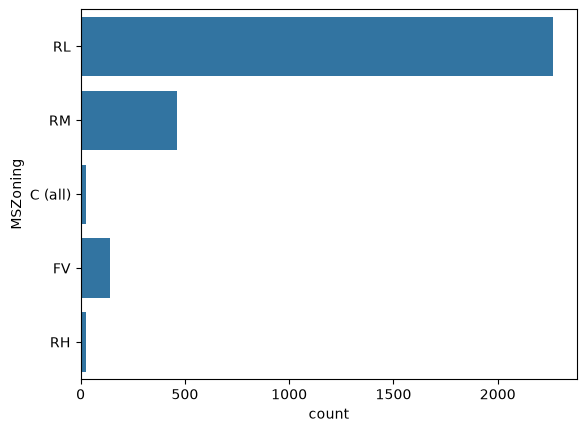

In [35]:
sns.countplot(df["MSZoning"])

### Backup of original data

In [36]:
df_mvi = df.copy()
df_mvi.shape

(2919, 81)

In [37]:

# find the most frequent value in the column
mszoning_mode = df["MSZoning"].mode()[0]

# replace NaN safely without using inplace=True
df_mvi["MSZoning"] = df_mvi["MSZoning"].replace(np.nan, mszoning_mode)

# verify that no missing values are left (should output 0)
df_mvi["MSZoning"].isnull().sum()

np.int64(0)

<Axes: xlabel='MSZoning', ylabel='count'>

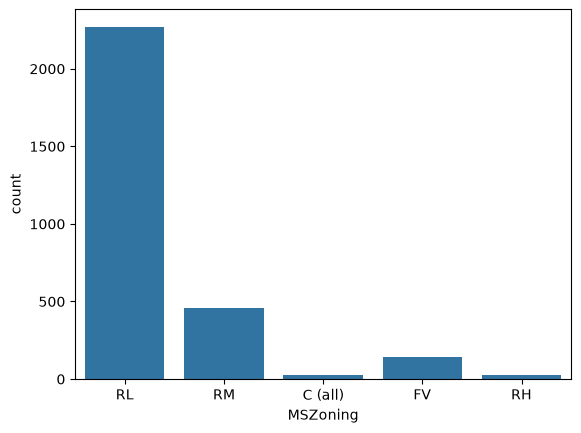

In [38]:
# plot vertical count of each category in MSZoning
sns.countplot(x="MSZoning", data=df_mvi)

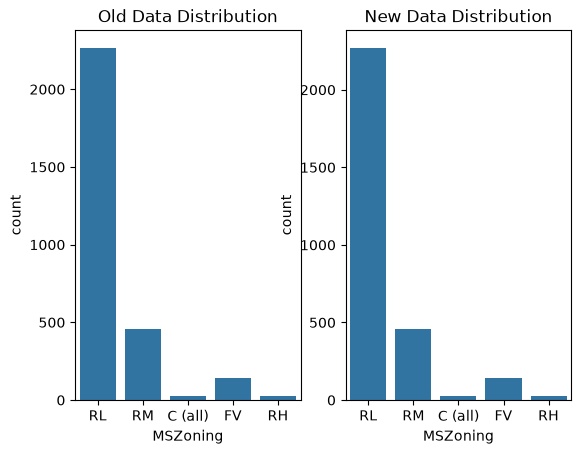

In [39]:
def oldNewCountPlot(df, df_new, feature):
    # reset index inside function to prevent duplicate label errors
    df = df.reset_index(drop=True)
    df_new = df_new.reset_index(drop=True)
    
    # create left subplot for original data
    plt.subplot(121)
    sns.countplot(x=feature, data=df)
    plt.title("Old Data Distribution")

    # create right subplot for new data
    plt.subplot(122)
    sns.countplot(x=feature, data=df_new)
    plt.title("New Data Distribution")

    # display both plots side by side
    plt.show()

# call the function
oldNewCountPlot(df, df_mvi, "MSZoning")

### Handing Alley = 93.216855

In [40]:
df_mvi["Alley"].value_counts()

Alley
Grvl    120
Pave     78
Name: count, dtype: int64

In [41]:

# fill missing values with "NA" (no alley access)
alley_constant = "NA"

# fill missing values in the "Alley" column with the defined constant
df_mvi["Alley"] = df_mvi["Alley"].fillna(alley_constant)

# verify and display result

missing_count = df_mvi["Alley"].isnull().sum()
print(f"Missing Values: {missing_count}")
print("\nUpdated distribution:")
print(df_mvi["Alley"].value_counts())


Missing Values: 0

Updated distribution:
Alley
NA      2721
Grvl     120
Pave      78
Name: count, dtype: int64


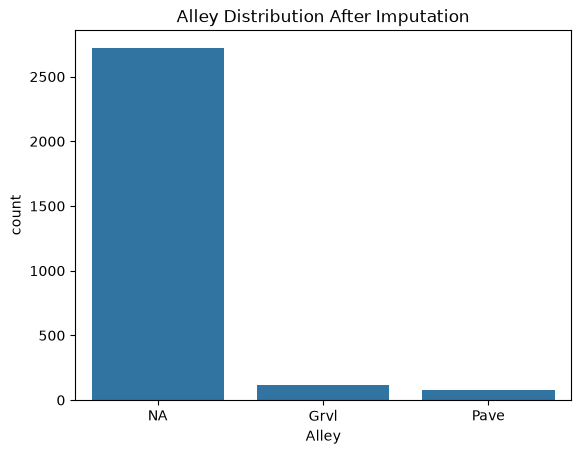

In [42]:
# visualize the updated Alley distribution
sns.countplot(x="Alley", data=df_mvi)
plt.title("Alley Distribution After Imputation")
plt.show()

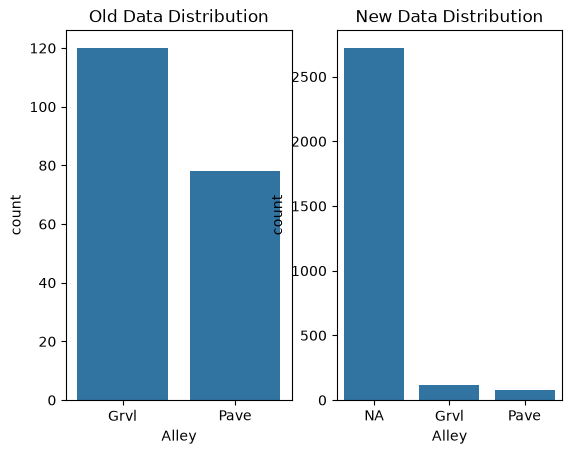

In [43]:
# define a resuable function that takes 3 inputs : original data , new_data, and column

def oldNewCountPlot(df, df_new, feature):
    """
    Compare distribution of a new feature before and after imputation.
    create side-by-side vertical countplots for visual verification 
    """

    # reset index of original data to remove duplicate labels (prevents seaborn error)
    df = df.reset_index(drop=True)


    #create the first subplot on the left side (1 raw, 2 columns , position 1)
    plt.subplot(121)

    # plot vertical bars of the feature from the original data
    sns.countplot(x=feature, data=df)
    plt.title("Old Data Distribution")

    # create the second subplot on the right side (1 row, 2 columns, position 2)
    plt.subplot(122)

    # plot vertical bars of the feature from the new data
    sns.countplot(x=feature, data=df_new)
    plt.title("New Data Distribution")

    # display the plots side by side
    plt.show()
oldNewCountPlot(df, df_mvi, "Alley")

In [44]:
print("Data Type of LotFrontage")
print(df["LotFrontage"].dtype)

print(df["LotFrontage"].head())

Data Type of LotFrontage
float64
0    65.0
1    80.0
2    68.0
3    60.0
4    84.0
Name: LotFrontage, dtype: float64


## Handling Lotfrontage

LotFrontage = 16.649538

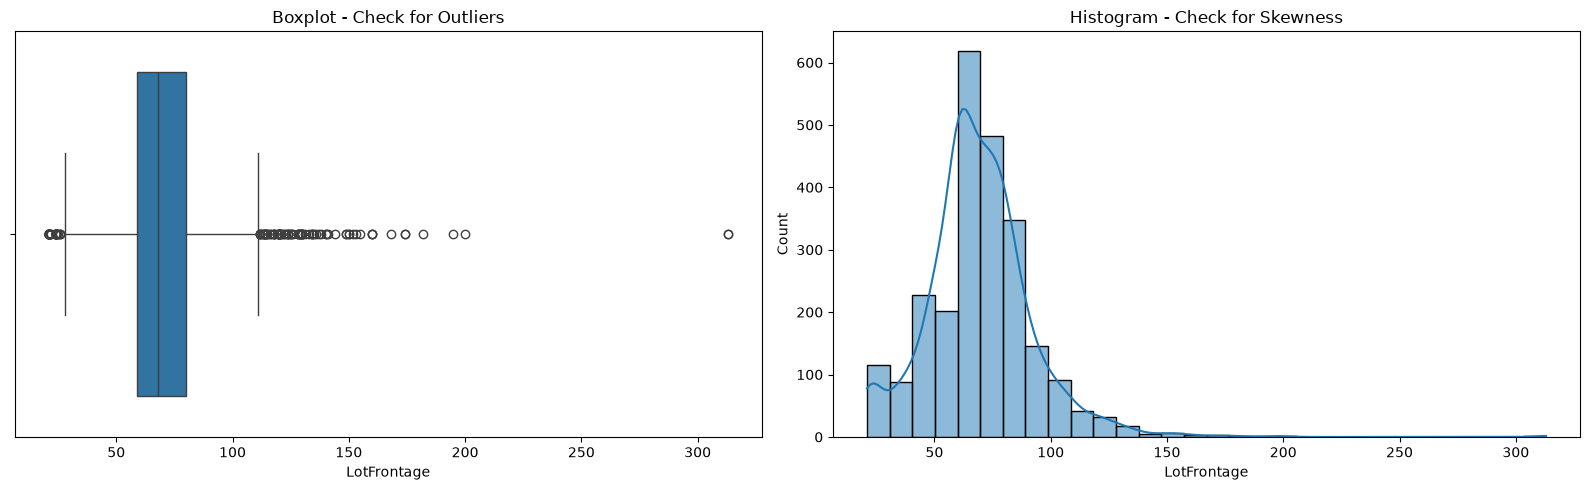

In [45]:
# define function to visualize numerical data distribution
# take data-frame (or series) and optional figure size as input
def boxHisplot(df, figsize=(16, 5)):
    """
    Create side-by-side boxplot & histogram for numerical data analysis.
    Helps decide whether to use mean or median for numerical data.
    """
    
    # reset the index to remove duplicate labels (this fixes the seaborn error!)
    df = df.reset_index(drop=True)
    
    # create a figure with specified size (default 16x5 inches)
    plt.figure(figsize=figsize)
    
    # create left subplot for boxplot (1 row, 2 columns, position 1)
    plt.subplot(1, 2, 1)
    
    # draw VERTICAL boxplot using x= parameter 
    # x= makes the boxplot stand upright instead of lying down
    sns.boxplot(x=df)
    
    # add a title to identify the plot
    plt.title("Boxplot - Check for Outliers")
    
    # create right subplot for histogram (1 row, 2 columns, position 2)
    plt.subplot(1, 2, 2)
    
    # draw histogram to see data distribution shape
    # histogram shows frequency of values in bins, kde adds a smooth curve
    sns.histplot(data=df, bins=30, kde=True)
    
    # add a title to identify the plot
    plt.title("Histogram - Check for Skewness")
    
    # adjust layout so titles and labels don't overlap
    plt.tight_layout()
    
    # display the plots on the screen
    plt.show()

# analyze LotFrontage column to decide mean or median
boxHisplot(df["LotFrontage"])

In [46]:
lot_frontage_mean = df["LotFrontage"].mean()
lot_frontage_mean

np.float64(69.30579531442663)

In [47]:
# step 1: calculate the mean from the original dataframe (prevents data leakage)
lot_frontage_mean = df["LotFrontage"].mean()

# step 2: fill missing values in df_mvi safely using direct assignment
# (avoiding inplace=True to prevent Pandas 2.0 errors)
df_mvi["LotFrontage"] = df_mvi["LotFrontage"].fillna(lot_frontage_mean)

# step 3: verify that no missing values are left in the column
print("Missing values after imputation:", df_mvi["LotFrontage"].isnull().sum())

Missing values after imputation: 0


In [48]:
# recreate df_mvi as a full DataFrame copy to fix the Series error
df_mvi = df.copy()

# now check if the column exists (this will work perfectly now)
print("LotFrontage in df_mvi:", "LotFrontage" in df_mvi.columns)

LotFrontage in df_mvi: True


In [49]:
# create a copy of orginial data_frmae

df_mvi = df.copy()

# confirm is the shape is same or not

print(df_mvi.shape)

(2919, 81)


## MSZoning Mode Imputation


In [50]:
msznoning_mode = df["MSZoning"].mode()[0]
print(f"MSZonining mode: {msznoning_mode}")

# Fill the missing values to mode
df_mvi["MSZoning"] = df_mvi["MSZoning"].replace(np.nan, msznoning_mode)

# verification 
print(f"MSZoning missing after imputation: {df_mvi['MSZoning'].isnull().sum()}")

MSZonining mode: RL
MSZoning missing after imputation: 0


## Alley missing values mean "No access"

In [51]:
df_mvi["Alley"] = df_mvi["Alley"].fillna("NA")

# After verification
print(f"Alley missing after imputation: {df_mvi['Alley'].isnull().sum()}")
print("\nAlley Counts: ")
print(df_mvi["Alley"].value_counts())

Alley missing after imputation: 0

Alley Counts: 
Alley
NA      2721
Grvl     120
Pave      78
Name: count, dtype: int64


# Calculate Mean of LotFrontage

In [52]:
# calculate the mean of lot frontage

lot_frontage_mean = df["LotFrontage"].mean()
print(f"LotFrontage mean: {lot_frontage_mean}")

# Fill the missing values with the mean
df_mvi["LotFrontage"] = df_mvi["LotFrontage"].replace(np.nan, lot_frontage_mean)

# verification after imputation
print(f"LotFrontage missing after imputation: {df_mvi['LotFrontage'].isnull().sum()}")

LotFrontage mean: 69.30579531442663
LotFrontage missing after imputation: 0


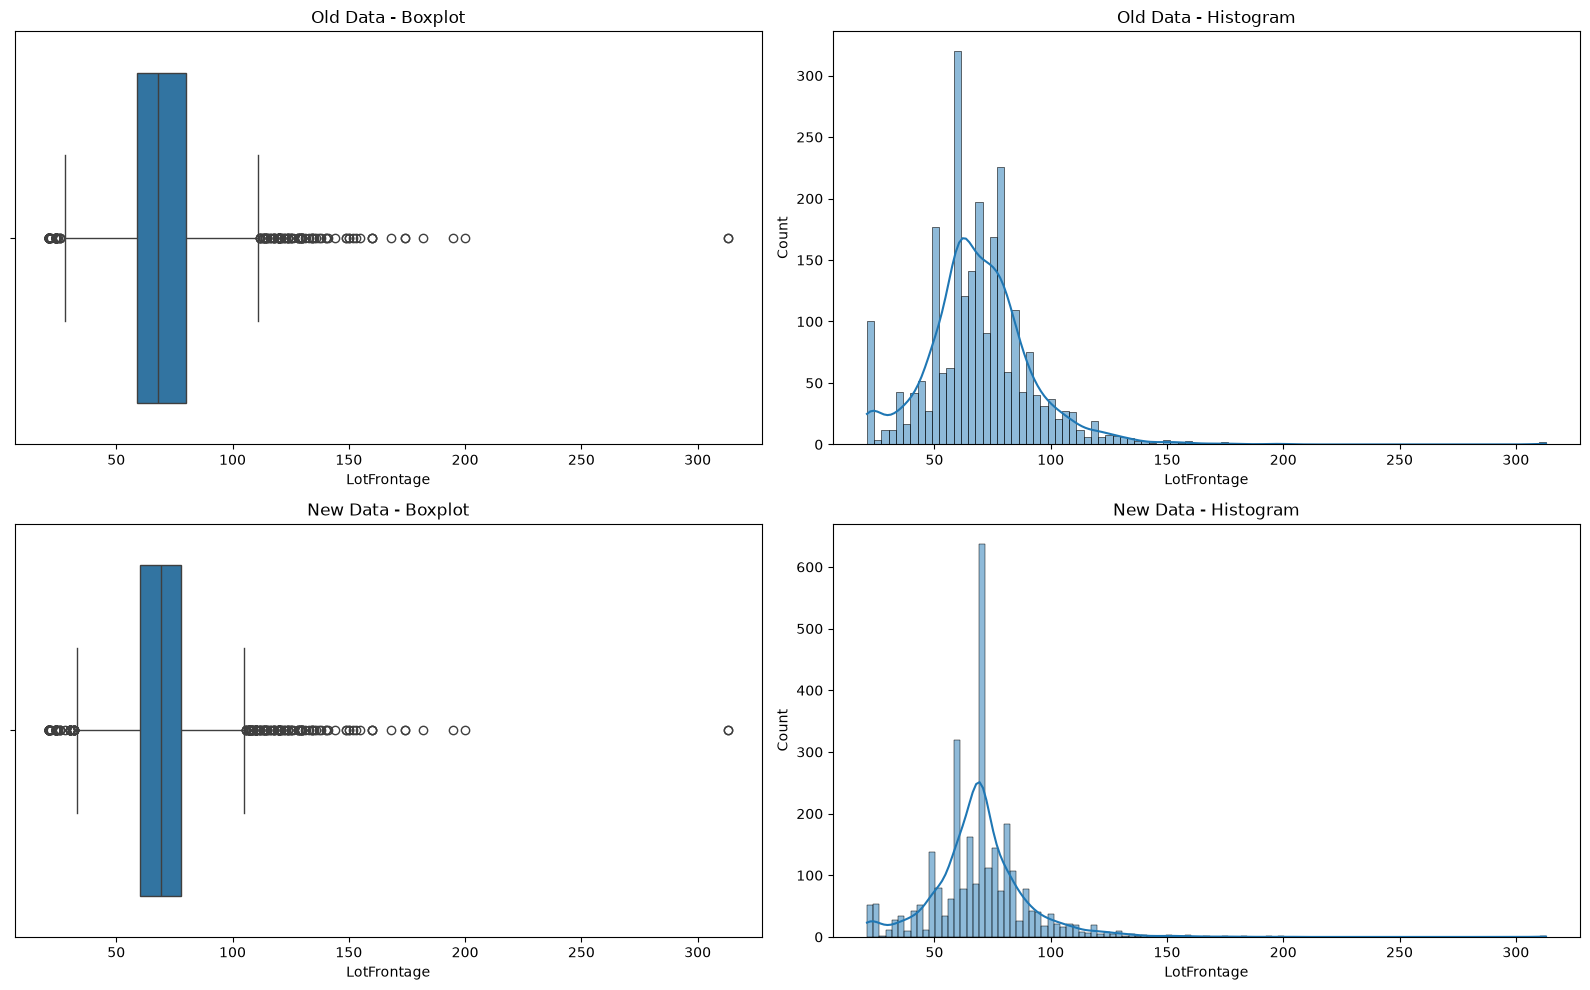

In [53]:
# Define a function to compare old and new distributions for a numerical feature
def oldNewBoxHistPlot(df, df_new, feature, figsize=(16, 10)):
    """
    Compare old and new distributions of a numerical feature.
    Creates 4 plots: old boxplot, old histogram, new boxplot, new histogram.
    """
    
    # Reset the index of the old dataframe to avoid duplicate label errors
    df = df.reset_index(drop=True)
    
    # Reset the index of the new dataframe to avoid duplicate label errors
    df_new = df_new.reset_index(drop=True)
    
    # Create a blank canvas with the given figure size
    plt.figure(figsize=figsize)
    
    # --- Plot 1: Old Data Boxplot (top-left position) ---
    # Create the first subplot in a 2x2 grid at position 1
    plt.subplot(2, 2, 1)
    # Draw a boxplot for the old data to see outliers and spread
    sns.boxplot(x=df[feature])
    # Add a title to the first plot
    plt.title("Old Data - Boxplot")
    
    # --- Plot 2: Old Data Histogram (top-right position) ---
    # Create the second subplot in a 2x2 grid at position 2
    plt.subplot(2, 2, 2)
    # Draw a histogram with a smooth curve (KDE) to see the distribution shape
    sns.histplot(df[feature], kde=True)
    # Add a title to the second plot
    plt.title("Old Data - Histogram")
    
    # --- Plot 3: New Data Boxplot (bottom-left position) ---
    # Create the third subplot in a 2x2 grid at position 3
    plt.subplot(2, 2, 3)
    # Draw a boxplot for the new data to see outliers and spread after imputation
    sns.boxplot(x=df_new[feature])
    # Add a title to the third plot
    plt.title("New Data - Boxplot")
    
    # --- Plot 4: New Data Histogram (bottom-right position) ---
    # Create the fourth subplot in a 2x2 grid at position 4
    plt.subplot(2, 2, 4)
    # Draw a histogram with a smooth curve (KDE) for the new data
    sns.histplot(df_new[feature], kde=True)
    # Add a title to the fourth plot
    plt.title("New Data - Histogram")
    
    # Adjust the spacing between plots so they do not overlap
    plt.tight_layout()
    
    # Display all four plots on the screen
    plt.show()

 # Call the function to compare old and new distributions of LotFrontage
oldNewBoxHistPlot(df, df_mvi, "LotFrontage")   

### Handling Utilities = 0.068517

In [54]:
# show the count of each category in the 'Utilities' column
df['Utilities'].value_counts()

Utilities
AllPub    2916
NoSeWa       1
Name: count, dtype: int64

In [55]:
# Find the most frequent values in the 'Utilities' column
utilities_Mode = df['Utilities'].mode()[0]

# Fill missing values in df_mvi with the mode value 
df_mvi['Utilities'] = df_mvi['Utilities'].replace(np.nan,utilities_Mode)


# Verify that no missing values are left
df_mvi['Utilities'].isnull().sum()

np.int64(0)

### Handling Exterior1st = 0.034258 and Exterior2nd = 0.034258

In [56]:
df["Exterior1st"].value_counts()

Exterior1st
VinylSd    1025
MetalSd     450
HdBoard     442
Wd Sdng     411
Plywood     221
CemntBd     126
BrkFace      87
WdShing      56
AsbShng      44
Stucco       43
BrkComm       6
AsphShn       2
Stone         2
CBlock        2
ImStucc       1
Name: count, dtype: int64

In [57]:
df["Exterior2nd"].value_counts()

Exterior2nd
VinylSd    1014
MetalSd     447
HdBoard     406
Wd Sdng     391
Plywood     270
CmentBd     126
Wd Shng      81
BrkFace      47
Stucco       47
AsbShng      38
Brk Cmn      22
ImStucc      15
Stone         6
AsphShn       4
CBlock        3
Other         1
Name: count, dtype: int64

In [58]:
# Find the most frequent value in the Exterior1st column
exterior1st_mode = df["Exterior1st"].mode()[0]


# Find the most frequent value in the Exterior2nd column
exterior2nd_mode = df["Exterior2nd"].mode()[0]

# Fill missing values in Exterior1st with its mode value
df_mvi["Exterior1st"] = df_mvi["Exterior1st"].replace(np.nan, exterior1st_mode)

# Fill missing values in Exterior2nd with its mode value
df_mvi["Exterior2nd"] = df_mvi["Exterior2nd"].replace(np.nan, exterior2nd_mode)

# Verify that no missing values are left in Exterior1st
print("Exterior1st null count:", df_mvi["Exterior1st"].isnull().sum())

print("Exterior2nd null count:", df_mvi["Exterior2nd"].isnull().sum())

Exterior1st null count: 0
Exterior2nd null count: 0


### Handling MasVnrType = 60.500171 and MasVnrArea = 0.787941

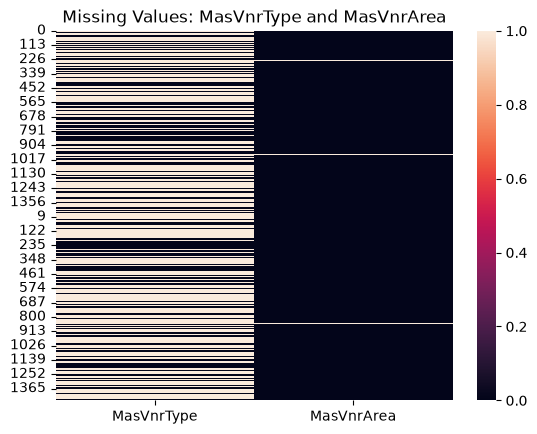

In [59]:
#create a heatmap to visualize missing values in both columns

sns.heatmap(df[["MasVnrType", "MasVnrArea"]].isnull())

plt.title("Missing Values: MasVnrType and MasVnrArea")
plt.show()

In [60]:
df[df[["MasVnrType", "MasVnrArea"]].isnull().any(axis=1)]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,Ex,Y,SBrkr,1262,0,0,1262,0.0,1.0,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2.0,460.0,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,Gd,Y,SBrkr,961,756,0,1717,1.0,0.0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3.0,642.0,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1.5Fin,5,5,1993,1995,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,Wood,Gd,TA,No,GLQ,732.0,Unf,0.0,64.0,796.0,GasA,Ex,Y,SBrkr,796,566,0,1362,1.0,0.0,1,1,1,1,TA,5,Typ,0,NaN,Attchd,1993.0,Unf,2.0,480.0,TA,TA,Y,40,30,0,320,0,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000.0
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Artery,Norm,1Fam,1.5Fin,7,5,1931,1950,Gable,CompShg,BrkFace,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,TA,No,Unf,0.0,Unf,0.0,952.0,952.0,GasA,Gd,Y,FuseF,1022,752,0,1774,0.0,0.0,2,0,2,2,TA,8,Min1,2,TA,Detchd,1931.0,Unf,2.0,468.0,Fa,TA,Y,90,0,205,0,0,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900.0
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,BrkSide,Artery,Artery,2fmCon,1.5Unf,5,6,1939,1950,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,BrkTil,TA,TA,No,GLQ,851.0,Unf,0.0,140.0,991.0,GasA,Ex,Y,SBrkr,1077,0,0,1077,1.0,0.0,1,0,2,2,TA,5,Typ,2,TA,Attchd,1939.0,RFn,1.0,205.0,Gd,TA,Y,0,4,0,0,0,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000.0
10,11,20,RL,70.0,11200,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Sawyer,Norm,Norm,1Fam,1Story,5,5,1965,1965,Hip,CompShg,HdBoard,HdBoard,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,906.0,Unf,0.0,134.0,1040.0,GasA,Ex,Y,SBrkr,1040,0,0,1040,1.0,0.0,1,0,3,1,TA,5,Typ,0,NaN,Detchd,1965.0,Unf,1.0,384.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,129500.0
12,13,20,RL,NaN,12968,Pave,NaN,IR2,Lvl,AllPub,Inside,Gtl,Sawyer,Norm,Norm,1Fam,1Story,5,6,1962,1962,Hip,CompShg,HdBoard,Plywood,NaN,0.0,TA,TA,CBlock,TA,TA,No,ALQ,737.0,Unf,0.0,175.0,912.0,GasA,TA,Y,SBrkr,912,0,0,912,1.0,0.0,1,0,2,1,TA,4,Typ,0,NaN,Detchd,1962.0,Unf,1.0,352.0,TA,TA,Y,140,0,0,0,176,0,NaN,NaN,NaN,0,9,2008,WD,Normal,144000.0
15,16,45,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,BrkSide,Norm,Norm,1Fam,1.5Unf,7,8,1929,2001,Gable,CompShg,Wd Sdng,Wd Sdng,NaN,0.0,TA,TA,BrkTil,TA,TA,No,Unf,0.0,Unf,0.0,832.0,832.0,GasA,Ex,Y,FuseA,854,0,0,854,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Detchd,1991.0,Unf,2.0,576.0,TA,TA,Y,48,112,0,0,0,0,NaN,GdPrv,NaN,0,7,2007,WD,Normal,132000.0
17,18,90,RL,72.0,10791,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Sawyer,Norm,Norm,Duplex,1Story,4,5,1967,1967,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,Slab,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.0,0.0,GasA,TA,Y,SBrkr,1296,0,0,1296,0.0,0.0,2,0,2,2,TA,6,Typ,0,NaN,CarPort,1967.0,Unf,2.0,516.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000.0
18,19,20,RL,66.0,13695,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,SawyerW,RR

In [61]:
df["MasVnrType"].value_counts()

MasVnrType
BrkFace    879
Stone      249
BrkCmn      25
Name: count, dtype: int64

In [62]:
# Find the most frequent value in the MasVnrType column
mass_vnr_type_mode = df["MasVnrType"].mode()[0]

# Print the mode value to check it
print(f"MasVnrType mode: {mass_vnr_type_mode}")


# Fill the missing values in the MasVnrType column with the mode value
df_mvi["MasVnrType"] = df_mvi["MasVnrType"].replace(np.nan, mass_vnr_type_mode)

# Verify that no missing values are left
print(f"MasVnrType missing values after imputation: {df_mvi['MasVnrType'].isnull().sum()}")

MasVnrType mode: BrkFace
MasVnrType missing values after imputation: 0


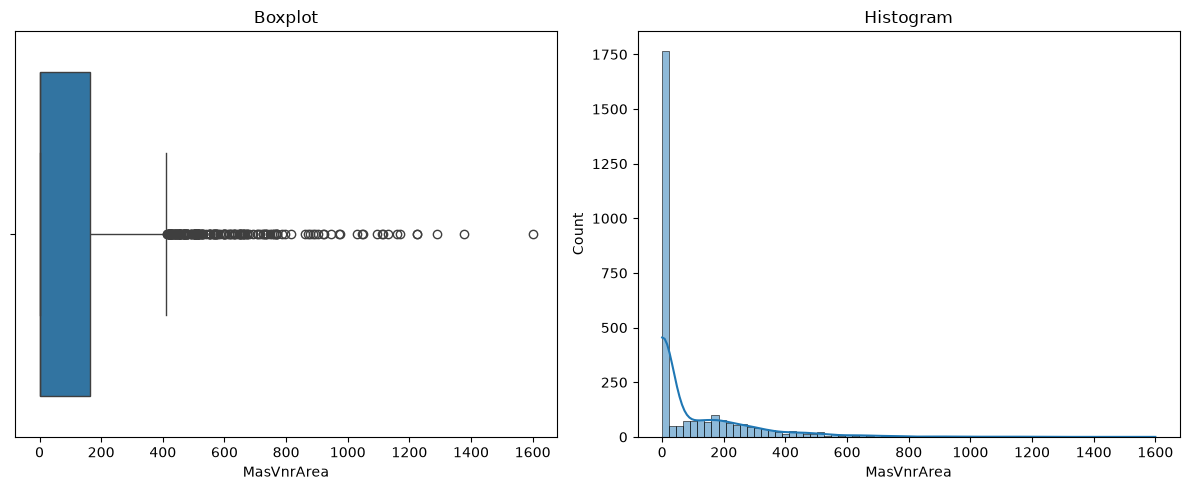

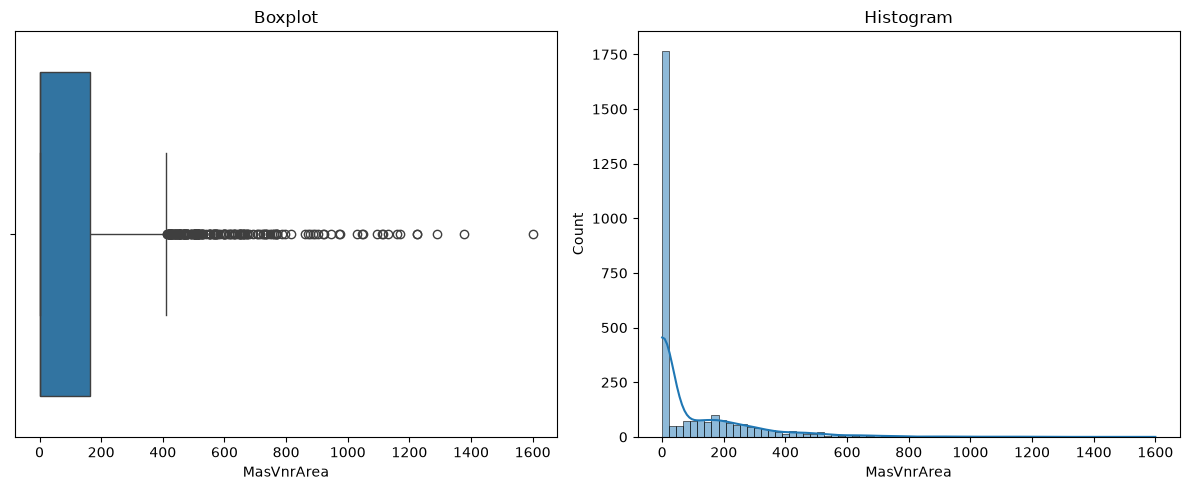

In [63]:
# Define a function to show boxplot and histogram for a single feature
def boxHistPlot(series, figsize=(12, 5)):
    """
    Show boxplot and histogram for a single numerical feature.
    """
    
    # Reset the index of the series to avoid duplicate label errors
    series = series.reset_index(drop=True)
    
    # Create a blank canvas with the given figure size
    plt.figure(figsize=figsize)
    
    # --- Plot 1: Boxplot (left side) ---
    # Create the first subplot in a 1x2 grid at position 1
    plt.subplot(1, 2, 1)
    # Draw a boxplot to see outliers and spread
    sns.boxplot(x=series)
    # Add a title
    plt.title("Boxplot")
    
    # --- Plot 2: Histogram (right side) ---
    # Create the second subplot in a 1x2 grid at position 2
    plt.subplot(1, 2, 2)
    # Draw a histogram with a smooth curve (KDE)
    sns.histplot(series, kde=True)
    # Add a title
    plt.title("Histogram")
    
    # Adjust spacing so plots do not overlap
    plt.tight_layout()
    
    # Display both plots
    plt.show()


boxHistPlot(df["MasVnrArea"])
boxHistPlot(df_mvi["MasVnrArea"])       

In [64]:
# Set the mode value for MasVnrArea as 0

masvnrmode_area = 0

# Fill missing values in df_mvi with the mode value (0)
df_mvi["MasVnrArea"] = df_mvi["MasVnrArea"].replace(np.nan, masvnrmode_area)

# Verify that no missing values are left
print("MasVnrArea missing after imputation:", df_mvi["MasVnrArea"].isnull().sum())

MasVnrArea missing after imputation: 0


### Handling BSmt Handling Feature

In [65]:
# Create a list of Categorical basement features
cat_bsmt_feat = [
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",

]

# print the list to verify
print("Categorical basement features:")
print(cat_bsmt_feat)

Categorical basement features:
['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']


In [66]:
# Create a list of Numerical basement features
num_bsmt_feat = [
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "BsmtFullBath",
    "BsmtHalfBath"
]

# print the list to verify
print("Numerical basement features:")
print(num_bsmt_feat)

Numerical basement features:
['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath']


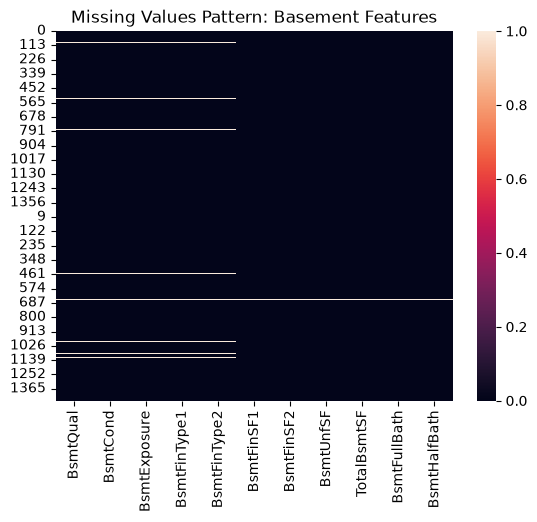

In [67]:
# Understand the Pattern via heatmap
sns.heatmap(df[cat_bsmt_feat + num_bsmt_feat].isnull())
plt.title("Missing Values Pattern: Basement Features")
plt.show()

In [69]:
# Loop through each categorical basement feature
for feature in cat_bsmt_feat:
    print(f"value count of {feature}: {df[feature].value_counts()}")


value count of BsmtQual: BsmtQual
TA    1283
Gd    1209
Ex     258
Fa      88
Name: count, dtype: int64
value count of BsmtCond: BsmtCond
TA    2606
Gd     122
Fa     104
Po       5
Name: count, dtype: int64
value count of BsmtExposure: BsmtExposure
No    1904
Av     418
Gd     276
Mn     239
Name: count, dtype: int64
value count of BsmtFinType1: BsmtFinType1
Unf    851
GLQ    849
ALQ    429
Rec    288
BLQ    269
LwQ    154
Name: count, dtype: int64
value count of BsmtFinType2: BsmtFinType2
Unf    2493
Rec     105
LwQ      87
BLQ      68
ALQ      52
GLQ      34
Name: count, dtype: int64


In [70]:
# Loop through each categorical basement feature
for feature in cat_bsmt_feat:
    # Fill the missing value with "NA" (No Basement)
    df_mvi[feature] = df_mvi[feature].fillna("NA")

    # Print the feature name and missing count after imputation
    print(f"{feature} missing after imputation : {df_mvi[feature].isnull().sum()}")

BsmtQual missing after imputation : 0
BsmtCond missing after imputation : 0
BsmtExposure missing after imputation : 0
BsmtFinType1 missing after imputation : 0
BsmtFinType2 missing after imputation : 0


In [73]:
df_bsmt = df[cat_bsmt_feat + num_bsmt_feat]
df_bsmt[df_bsmt.isnull().any(axis=1)]

,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,BsmtFullBath,BsmtHalfBath
17,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
39,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
90,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
102,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
156,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
182,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
259,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
332,Gd,TA,No,GLQ,NaN,1124.0,479.0,1603.0,3206.0,1.0,0.0
342,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
362,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0


In [74]:
# Loop through each numerical basement feature
for feature in num_bsmt_feat:
    #Fill missing values with 0 (No Basement)
    df_mvi[feature] = df_mvi[feature].fillna(0)

    #print the feature name and missing count after imputation
    print(f"{feature} missing count after imputation: {df_mvi[feature].isnull().sum()}")

BsmtFinSF1 missing count after imputation: 0
BsmtFinSF2 missing count after imputation: 0
BsmtUnfSF missing count after imputation: 0
TotalBsmtSF missing count after imputation: 0
BsmtFullBath missing count after imputation: 0
BsmtHalfBath missing count after imputation: 0


### Handling Electrical = 0.034258 KitchenQual = 0.034258

In [76]:
df["Electrical"].value_counts()

Electrical
SBrkr    2671
FuseA     188
FuseF      50
FuseP       8
Mix         1
Name: count, dtype: int64

In [77]:
df["KitchenQual"].value_counts()

KitchenQual
TA    1492
Gd    1151
Ex     205
Fa      70
Name: count, dtype: int64

In [78]:
# Show rows where Electrical, KitchenQual, or KitchenAbvGr is missing
df_ekk = df[[ "Electrical", "KitchenQual", "KitchenAbvGr"]]
df_ekk[df_ekk.isnull().any(axis=1)]


,Electrical,KitchenQual,KitchenAbvGr
1379,NaN,Gd,1
95,SBrkr,NaN,1


In [79]:
# Find the most frequent value in the Electrical column
electrical_mode = df["Electrical"].mode()[0]


# Fill missing values in the df_mvi with the mode value
df_mvi["Electrical"] = df_mvi["Electrical"].fillna(electrical_mode)


# Verify that no missing values are left
print("Electrical missing after imputation: ", df_mvi["Electrical"].isnull().sum())

Electrical missing after imputation:  0


### Handling Remaining Cat Feature

In [81]:
df["Functional"].value_counts()

Functional
Typ     2717
Min2      70
Min1      65
Mod       35
Maj1      19
Maj2       9
Sev        2
Name: count, dtype: int64

In [82]:
df["SaleType"].value_counts()

SaleType
WD       2525
New       239
COD        87
ConLD      26
CWD        12
ConLI       9
ConLw       8
Oth         7
Con         5
Name: count, dtype: int64

In [83]:
# Find the most frequent value in the Functional column

functional_mode = df["Functional"].mode()[0]

# Print the mode value to check it
print(f"Functional Mode: {functional_mode}")


# Fill missing values in df_mvi with the mode value
df_mvi["Functional"] = df_mvi["Functional"].replace(np.nan, functional_mode)

# Verify that no missing values are left
print("Functional missing after imputation: ", df_mvi["Functional"].isnull().sum())

Functional Mode: Typ
Functional missing after imputation:  0


In [84]:
# Find the most frequent value in the SaleType column

saletype_mode = df["SaleType"].mode()[0]

# Print the mode value to check it
print(f"SaleType Mode: {saletype_mode}")

# Fill missing values in df_mvi with the mode value
df_mvi["SaleType"] = df_mvi["SaleType"].replace(np.nan, saletype_mode)

# Verify that no missing values are left
print("SaleType missing after imputation:", df_mvi["SaleType"].isnull().sum())

SaleType Mode: WD
SaleType missing after imputation: 0


In [85]:
# Create a list of other categorical features with high missing values

other_cat_feat = ["FireplaceQu", "PoolQC", "Fence", "MiscFeature"]

# Loop through each feature and print its value counts
for feat in other_cat_feat:
    print(f"Value count of {feat}:")
    print(df[feat].value_counts())
    print("-" * 40)

Value count of FireplaceQu:
FireplaceQu
Gd    744
TA    592
Fa     74
Po     46
Ex     43
Name: count, dtype: int64
----------------------------------------
Value count of PoolQC:
PoolQC
Ex    4
Gd    4
Fa    2
Name: count, dtype: int64
----------------------------------------
Value count of Fence:
Fence
MnPrv    329
GdPrv    118
GdWo     112
MnWw      12
Name: count, dtype: int64
----------------------------------------
Value count of MiscFeature:
MiscFeature
Shed    95
Gar2     5
Othr     4
TenC     1
Name: count, dtype: int64
----------------------------------------


In [86]:
# Fill missing values in FireplaceQu with "NA" (No Fireplace)
df_mvi["FireplaceQu"] = df_mvi["FireplaceQu"].fillna("NA")
print("FireplaceQu missing after imputation:", df_mvi["FireplaceQu"].isnull().sum())

# Fill missing values in PoolQC with "NA" (No Pool)
df_mvi["PoolQC"] = df_mvi["PoolQC"].fillna("NA")
print("PoolQC missing after imputation:", df_mvi["PoolQC"].isnull().sum())

# Fill missing values in Fence with "NA" (No Fence)
df_mvi["Fence"] = df_mvi["Fence"].fillna("NA")
print("Fence missing after imputation:", df_mvi["Fence"].isnull().sum())

# Fill missing values in MiscFeature with "NA" (None)
df_mvi["MiscFeature"] = df_mvi["MiscFeature"].fillna("NA")
print("MiscFeature missing after imputation:", df_mvi["MiscFeature"].isnull().sum())

FireplaceQu missing after imputation: 0
PoolQC missing after imputation: 0
Fence missing after imputation: 0
MiscFeature missing after imputation: 0


In [87]:
# Check karo ke KitchenQual mein abhi bhi missing values hain ya nahi
print("KitchenQual missing:", df_mvi["KitchenQual"].isnull().sum())

KitchenQual missing: 1


In [88]:
df["KitchenQual"].value_counts()

KitchenQual
TA    1492
Gd    1151
Ex     205
Fa      70
Name: count, dtype: int64

In [89]:
kitchenqual_mode = df["KitchenQual"].mode()[0]

print(f"KitchenQual Mode: {kitchenqual_mode}")

df_mvi["KitchenQual"] = df_mvi["KitchenQual"].fillna(kitchenqual_mode)

print("KitchenQual missing after imputation:", df_mvi["KitchenQual"].isnull().sum())

KitchenQual Mode: TA
KitchenQual missing after imputation: 0


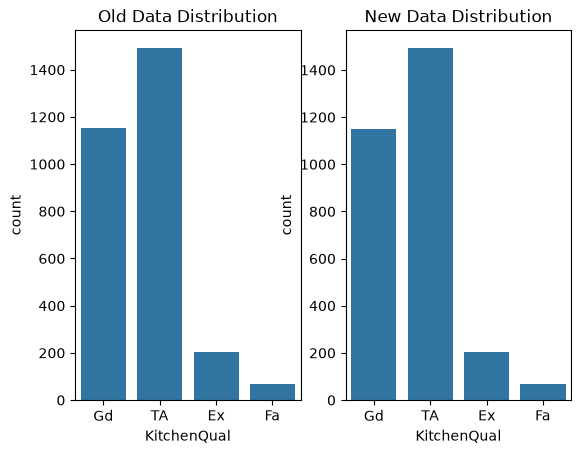

In [90]:
oldNewCountPlot(df, df_mvi, "KitchenQual")